In [18]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.api as sm
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

sns.set(color_codes=True) 

import warnings
warnings.filterwarnings('ignore')

In [19]:
file = r"C:\Users\TUGCE\Desktop\data_analytics\synthetic_userdata_app.csv"
df = pd.read_csv(file, encoding="utf-8")
print(df.shape)

(150, 10)


In [20]:
df.head(10)

,UID,AcquisitionSource,Platform,TotalSessions,LevelsCompleted,BadgesEarned,PurchaseAmount,AvgSessionLength_Min,RecentSessionDate,ChurnRisk
0,2001,OrganicLanding,Android,13,0,6,0.00,16.82,2025-10-09,0
1,2002,GoogleAds,iOS,9,7,8,0.00,11.45,2025-08-22,0
2,2003,OrganicLanding,iOS,22,13,8,4.99,6.87,2025-08-08,0
3,2004,OrganicLanding,iOS,24,1,5,0.00,8.65,2025-09-21,0
4,2005,MetaAds,Android,24,16,6,4.99,6.83,2025-10-22,0
5,2006,OrganicLanding,iOS,15,1,5,0.00,18.25,2025-10-01,0
6,2007,OrganicLanding,iOS,15,7,6,0.00,13.32,2025-08-25,0
7,2008,GoogleAds,iOS,24,5,0,0.00,13.29,2025-10-10,0
8,2009,OrganicLanding,Android,29,19,4,4.99,10.70,2025-10-09,0
9,2010,GoogleAds,iOS,22,16,9,4.99,5.44,2025-10-06,0


In [21]:
df.columns

Index(['UID', 'AcquisitionSource', 'Platform', 'TotalSessions',
       'LevelsCompleted', 'BadgesEarned', 'PurchaseAmount',
       'AvgSessionLength_Min', 'RecentSessionDate', 'ChurnRisk'],
      dtype='object')

In [22]:
df.dtypes

UID                       int64
AcquisitionSource        object
Platform                 object
TotalSessions             int64
LevelsCompleted           int64
BadgesEarned              int64
PurchaseAmount          float64
AvgSessionLength_Min    float64
RecentSessionDate        object
ChurnRisk                 int64
dtype: object

In [23]:
df.isnull().sum()

UID                     0
AcquisitionSource       0
Platform                0
TotalSessions           0
LevelsCompleted         0
BadgesEarned            0
PurchaseAmount          0
AvgSessionLength_Min    0
RecentSessionDate       0
ChurnRisk               0
dtype: int64

In [24]:
df.isna().sum()

UID                     0
AcquisitionSource       0
Platform                0
TotalSessions           0
LevelsCompleted         0
BadgesEarned            0
PurchaseAmount          0
AvgSessionLength_Min    0
RecentSessionDate       0
ChurnRisk               0
dtype: int64

In [25]:
df.duplicated

<bound method DataFrame.duplicated of       UID AcquisitionSource Platform  TotalSessions  LevelsCompleted  \
0    2001    OrganicLanding  Android             13                0   
1    2002         GoogleAds      iOS              9                7   
2    2003    OrganicLanding      iOS             22               13   
3    2004    OrganicLanding      iOS             24                1   
4    2005           MetaAds  Android             24               16   
..    ...               ...      ...            ...              ...   
145  2146           MetaAds  Android             16               18   
146  2147           MetaAds  Android             22               19   
147  2148    OrganicLanding  Android             28                2   
148  2149    OrganicLanding  Android             21                8   
149  2150         GoogleAds  Android              7                0   

     BadgesEarned  PurchaseAmount  AvgSessionLength_Min RecentSessionDate  \
0               6   

In [26]:
df["ChurnRisk"].unique()

array([0, 1])

In [27]:
df["AcquisitionSource"].unique()

array(['OrganicLanding', 'GoogleAds', 'MetaAds'], dtype=object)

In [28]:
df["Platform"].unique()

array(['Android', 'iOS'], dtype=object)

In [29]:
df["TotalSessions"].value_counts()

TotalSessions
15    13
22     9
18     9
1      9
27     8
17     7
20     7
8      7
24     7
7      7
16     6
6      6
3      6
14     5
2      5
4      5
28     4
11     4
21     4
9      3
29     3
10     3
26     3
13     2
5      2
19     2
23     2
12     1
25     1
Name: count, dtype: int64

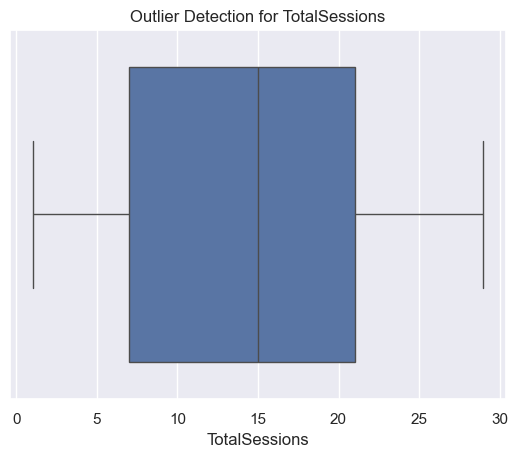

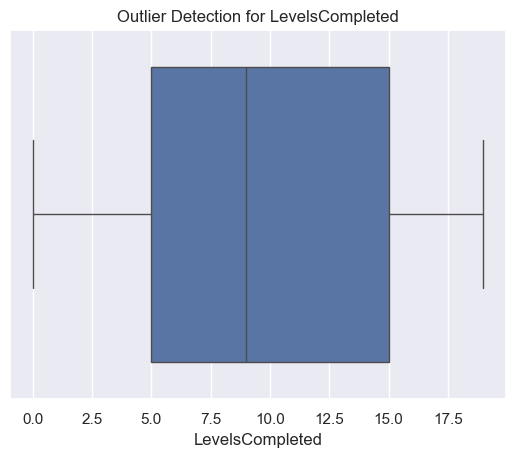

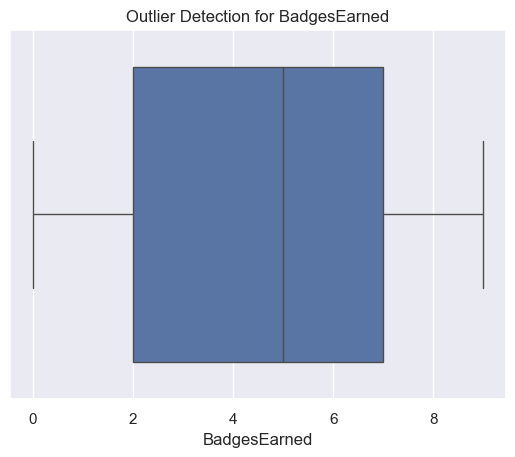

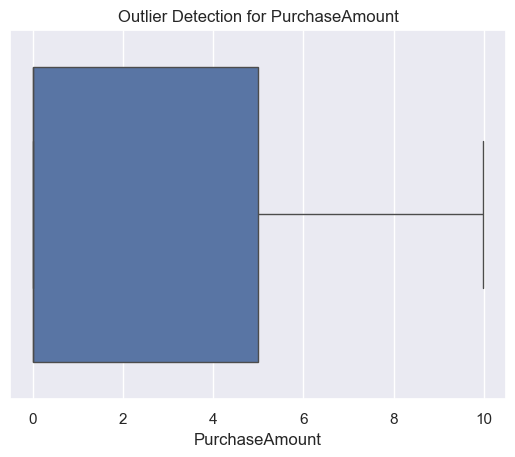

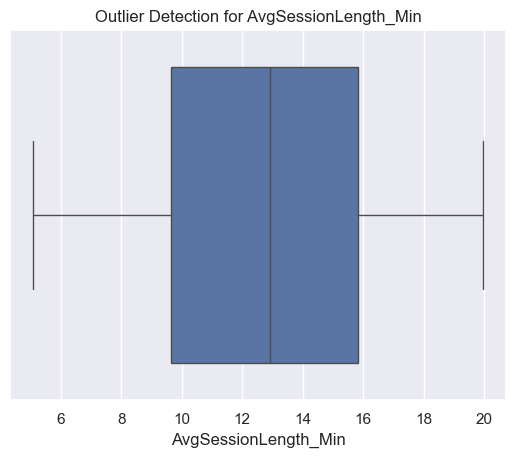

In [30]:
#CheckOutliers

numerical_cols = [
    'TotalSessions',
    'LevelsCompleted',
    'BadgesEarned',
    'PurchaseAmount',
    'AvgSessionLength_Min'
]

for col in numerical_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Outlier Detection for {col}')
    plt.show()


In [31]:
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] < lower) | (df[col] > upper)]

for col in numerical_cols:
    outliers = detect_outliers(df, col)
    print(f"{col}: {len(outliers)} outliers")

TotalSessions: 0 outliers
LevelsCompleted: 0 outliers
BadgesEarned: 0 outliers
PurchaseAmount: 0 outliers
AvgSessionLength_Min: 0 outliers


In [35]:
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, roc_auc_score,
    f1_score, precision_score, recall_score, log_loss
)

# Dark theme matching Vertex AI
plt.rcParams.update({
    'figure.facecolor': '#1e1e2e',
    'axes.facecolor':   '#252535',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#ccccdd',
    'xtick.color':      '#ccccdd',
    'ytick.color':      '#ccccdd',
    'text.color':       '#e0e0f0',
    'grid.color':       '#33334d',
    'grid.linestyle':   '--',
    'grid.alpha':        0.6,
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight': 'bold',
})

BLUE = '#5b9bd5'
PINK = '#e07b9a'
print("Libraries loaded ✓")

Libraries loaded ✓


In [36]:
df['RecentSessionDate'] = pd.to_datetime(df['RecentSessionDate'])
ref_date = df['RecentSessionDate'].max()
df['DaysSinceSession'] = (ref_date - df['RecentSessionDate']).dt.days

for col in ['AcquisitionSource', 'Platform']:
    df[col] = LabelEncoder().fit_transform(df[col])

feature_cols = [
    'TotalSessions', 'PurchaseAmount', 'AvgSessionLength_Min',
    'AcquisitionSource', 'BadgesEarned', 'Platform',
    'UID', 'LevelsCompleted', 'DaysSinceSession'
]

X = df[feature_cols]
y = df['ChurnRisk'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (120, 9), Test: (30, 9)


In [37]:
model = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42
)
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

print(f"ROC AUC : {roc_auc_score(y_test, y_proba):.3f}")
print(f"PR  AUC : {average_precision_score(y_test, y_proba):.3f}")

ROC AUC : 1.000
PR  AUC : 1.000


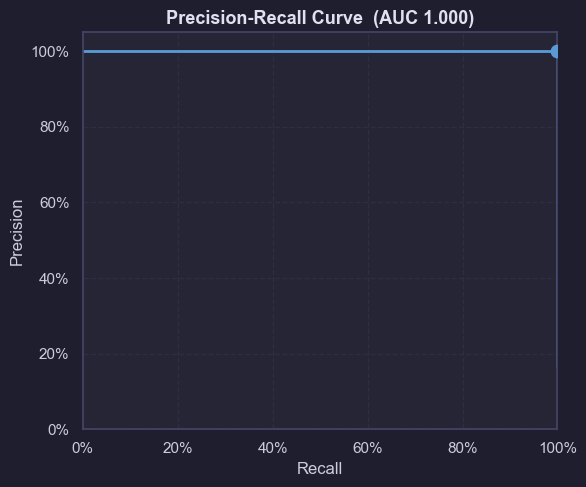

In [38]:
prec, rec, pr_thresh = precision_recall_curve(y_test, y_proba)
pr_auc_val = average_precision_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(rec, prec, color=BLUE, lw=2)

# Dot at threshold = 0.5
idx = np.argmin(np.abs(pr_thresh - 0.5))
ax.scatter([rec[idx]], [prec[idx]], color=BLUE, s=80, zorder=5)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curve  (AUC {pr_auc_val:.3f})')
ax.grid(True)

plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

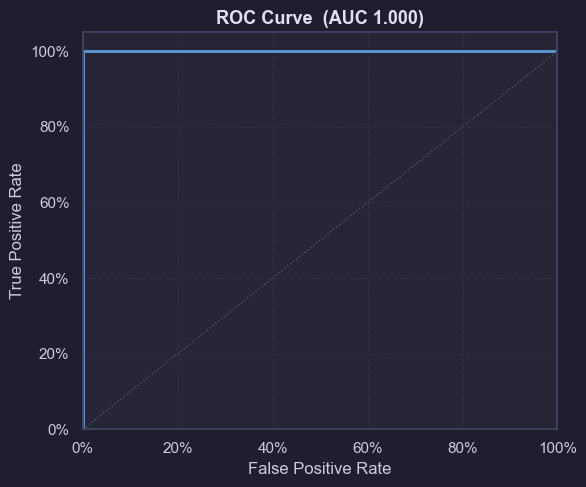

In [39]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc_val = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(fpr, tpr, color=BLUE, lw=2)
ax.plot([0, 1], [0, 1], color='#555577', lw=1, linestyle=':')  # random baseline

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curve  (AUC {roc_auc_val:.3f})')
ax.grid(True)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

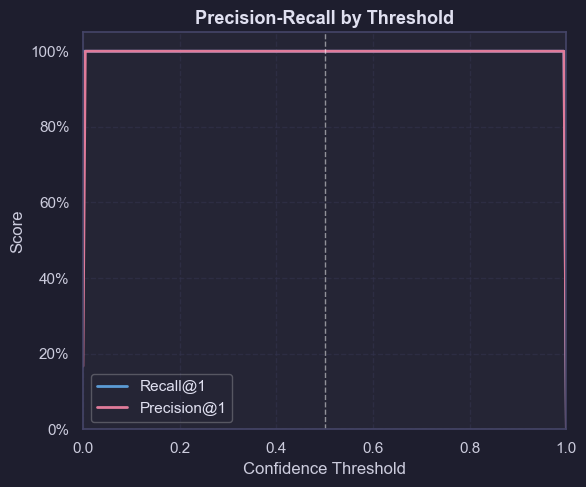

In [40]:
thresholds_plot = np.linspace(0, 1, 200)
prec_at_t, rec_at_t = [], []

for t in thresholds_plot:
    pred_t = (y_proba >= t).astype(int)
    tp = ((pred_t == 1) & (y_test == 1)).sum()
    fp = ((pred_t == 1) & (y_test == 0)).sum()
    fn = ((pred_t == 0) & (y_test == 1)).sum()
    prec_at_t.append(tp / (tp + fp + 1e-9))
    rec_at_t.append(tp  / (tp + fn + 1e-9))

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(thresholds_plot, rec_at_t,  color=BLUE, lw=2, label='Recall@1')
ax.plot(thresholds_plot, prec_at_t, color=PINK, lw=2, label='Precision@1')
ax.axvline(0.5, color='white', lw=1, linestyle='--', alpha=0.5)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('Confidence Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision-Recall by Threshold')
ax.legend(loc='lower left', framealpha=0.3)
ax.grid(True)

plt.tight_layout()
plt.savefig('precision_recall_by_threshold.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

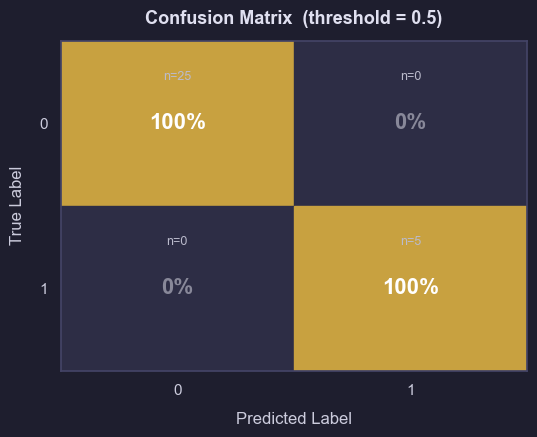

In [41]:
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(5.5, 4.5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#252535')

for i in range(2):
    for j in range(2):
        val   = cm_pct[i, j]
        color = '#c8a140' if i == j else '#2d2d45'
        ax.add_patch(plt.Rectangle([j - 0.5, i - 0.5], 1, 1, color=color))
        ax.text(j, i, f'{val:.0f}%',
                ha='center', va='center', fontsize=16, fontweight='bold',
                color='white' if i == j else '#888899')
        ax.text(j, i - 0.28, f'n={cm[i, j]}',
                ha='center', va='center', fontsize=9, color='#bbbbcc')

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xticks([0, 1]); ax.set_xticklabels(['0', '1'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['0', '1'])
ax.set_xlabel('Predicted Label', labelpad=10)
ax.set_ylabel('True Label',      labelpad=10)
ax.set_title('Confusion Matrix  (threshold = 0.5)', pad=12)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

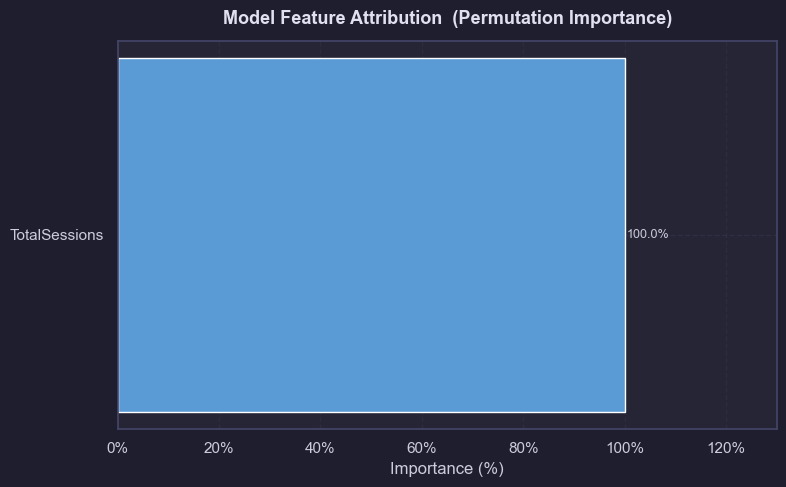

In [48]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_test, y_test, n_repeats=30, random_state=42)

feat_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': result.importances_mean
})
feat_df = feat_df[feat_df['Importance'] > 0]  # drop negatives
total   = feat_df['Importance'].sum()
feat_df['Importance'] = (feat_df['Importance'] / total) * 100
feat_df = feat_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color=BLUE, height=0.55)

ax.set_xlabel('Importance (%)')
ax.set_title('Model Feature Attribution  (Permutation Importance)', pad=12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlim(0, feat_df['Importance'].max() * 1.3)
ax.grid(axis='x', alpha=0.5)

for bar, val in zip(bars, feat_df['Importance']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, color='#ccccdd')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

In [43]:
metrics = {
    'PR AUC':                  round(average_precision_score(y_test, y_proba), 3),
    'ROC AUC':                 round(roc_auc_score(y_test, y_proba), 3),
    'Log loss':                round(log_loss(y_test, y_proba), 3),
    'Micro-average F1':        round(f1_score(y_test, y_pred, average='micro'), 7),
    'Macro-average F1':        round(f1_score(y_test, y_pred, average='macro'), 7),
    'Micro-average precision': f"{precision_score(y_test, y_pred, average='micro') * 100:.1f}%",
    'Micro-average recall':    f"{recall_score(y_test, y_pred,  average='micro') * 100:.1f}%",
}

pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])

,Value
PR AUC,1.0
ROC AUC,1.0
Log loss,0.0
Micro-average F1,1.0
Macro-average F1,1.0
Micro-average precision,100.0%
Micro-average recall,100.0%
